<div align="center"><h1><b>PROJECT: STOCHASTIC INTEREST RATE MODELING AND PREDICTION</b></h1></div>
<p align="right">
Finance Club, IIT Roorkee
</p>

# Introduction

- Interest rates play a central role in financial markets, influencing bond pricing, derivative valuation, and risk management. The relationship between interest rates and maturities is represented by the **yield curve**.

- To model the evolution of interest rates, this project uses the **Cox-Ingersoll-Ross (CIR) model**, a stochastic short-rate model in which interest rates follow a mean-reverting process.

- A key advantage of the CIR framework is its ability to maintain non-negative interest rates while providing closed-form bond pricing formulas.

- The objective of this project is to calibrate the CIR model using historical zero-coupon yield data through **Maximum Likelihood Estimation (MLE)**. The calibrated model is then used to reconstruct the entire yield curve using only the observed **3-Month (3M) yield** as input. Predicted yields are compared with actual market yields to evaluate out-of-sample performance.

- Since the standard CIR model is a single-factor model and may not fully capture yield curve dynamics, a **Two-Factor CIR model** is also implemented and evaluated. The performance of both models is compared.

# 1.1 Dataset Description

Three datasets are provided for this project:

| Dataset              | Description                                                           | Usage                                                                                                          |
| -------------------- | --------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **train_data.csv**   | Historical yield curve data containing all maturities from 3M to 30Y. | Used for data cleaning, exploratory data analysis (EDA), and calibration of the CIR and Two-Factor CIR models. |
| **test_data_3M.csv** | Test-period data containing only the 3-Month (3M) yield.              | Used as the sole input during yield curve reconstruction, as required by the problem statement.                |
| **test_data.csv**    | Test-period data containing the actual yield curve values.            | Used only for evaluating prediction accuracy and calculating performance metrics.                              |

### Yield Maturity Columns

| Column Name | Maturity              |
| ----------- | --------------------- |
| ZC025YR     | 3 Months (0.25 Years) |
| ZC050YR     | 6 Months (0.50 Years) |
| ZC075YR     | 9 Months (0.75 Years) |
| ZC100YR     | 1 Year                |
| ZC200YR     | 2 Years               |
| ZC500YR     | 5 Years               |
| ZC1000YR    | 10 Years              |
| ZC2000YR    | 20 Years              |
| ZC3000YR    | 30 Years              |

The columns represent daily zero-coupon yields at different maturities. During the prediction phase, only the 3-Month yield (ZC025YR) from `test_data_3M.csv` is used as an observable proxy for the short rate. The calibrated model is then used to reconstruct the remaining maturities of the yield curve and compare them against the actual values in `test_data.csv`.

In [47]:
# Description of the datasets

import pandas as pd
import numpy as np

# Load datasets
# The training dataset contains historical yield curves at multiple maturities.
# The test dataset contains full yield curve observations for out-of-sample evaluation.
# The test 3M dataset contains only the 3-month yield, which is used as the observed short rate.
train_df = pd.read_csv("https://raw.githubusercontent.com/unknowndx1651/Stochastic-Interest-Rate-Modeling/main/train_data.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/unknowndx1651/Stochastic-Interest-Rate-Modeling/main/test_data.csv")
test3m_df = pd.read_csv("https://raw.githubusercontent.com/unknowndx1651/Stochastic-Interest-Rate-Modeling/main/test_data_3M.csv")

# Dataset Shapes
print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("Test 3M Data Shape:", test3m_df.shape)

# Information about the datasets and first few rows
# This lets us verify that the column structure is correct and the data is in expected format.
print("===== TRAIN DATA =====")
train_df.info()
display(train_df.head(3))

print("\n===== TEST DATA =====")
test_df.info()
display(test_df.head(3))

print("\n===== TEST 3M DATA =====")
test3m_df.info()
display(test3m_df.head(3))

Train Data Shape: (1976, 10)
Test Data Shape: (495, 6)
Test 3M Data Shape: (495, 2)
===== TRAIN DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1976 non-null   object 
 1    ZC025YR   1976 non-null   float64
 2    ZC050YR   1976 non-null   float64
 3    ZC075YR   1976 non-null   float64
 4    ZC100YR   1976 non-null   float64
 5    ZC200YR   1976 non-null   float64
 6    ZC500YR   1976 non-null   float64
 7    ZC1000YR  1976 non-null   float64
 8    ZC2000YR  1976 non-null   float64
 9    ZC3000YR  1976 non-null   float64
dtypes: float64(9), object(1)
memory usage: 154.5+ KB


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793



===== TEST DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      495 non-null    object 
 1    ZC025YR  495 non-null    float64
 2    ZC050YR  495 non-null    float64
 3    ZC075YR  495 non-null    float64
 4    ZC100YR  495 non-null    float64
 5    ZC200YR  495 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.3+ KB


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449



===== TEST 3M DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      495 non-null    object 
 1    ZC025YR  495 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100


# 1.2 Data Cleaning and Preprocessing:

- Financial time-series data often contains missing values, inconsistencies, and extreme observations that adversely affect model calibration and prediction. Since the CIR model relies on accurately estimating the underlying short-rate dynamics, it is important to preprocess the data before performing any analysis.

In this project:

* Missing values (`NaN`, `null`, or empty entries) are handled using **forward filling (ffill)**, which propagates the most recently observed valid value forward.
* Outliers are detected using the **Interquartile Range (IQR)** method.
* Date columns are converted to proper datetime format and the datasets are sorted chronologically.

In [48]:
# Data Cleaning Function

def clean_yield_data(df):
    df = df.copy()

    # Convert date column to datetime so time-based sorting and indexing are correct.
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort chronologically so the temporal order of the short-rate path is preserved.
    df = df.sort_values('Date').reset_index(drop=True)

    # Replace common invalid entries with NaN for consistent missing value handling.
    df.replace(
        ['', ' ', 'NA', 'N/A', 'na', 'null', 'NULL', '-'],
        np.nan,
        inplace=True
    )

    # Convert yield columns to numeric values, coercing invalid strings to NaN.
    yield_cols = [col for col in df.columns if col != 'Date']

    for col in yield_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Forward fill missing values.
    # This assumes the most recent valid yield value is a reasonable estimate for the next observation.
    df[yield_cols] = df[yield_cols].ffill()

    # IQR Outlier Treatment: identify and clip values beyond 1.5 times the interquartile range.
    # This preserves the central distribution while reducing the impact of extreme outliers.
    for col in yield_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Clip outliers to IQR bounds
        df[col] = df[col].clip(lower_bound, upper_bound)
        
    return df

In [49]:
# Apply the data cleaning function
# Cleaning ensures that the yield series are continuous and that extreme values are bounded.
train_df_clean = clean_yield_data(train_df)
test_df_clean = clean_yield_data(test_df)
test3m_df_clean = clean_yield_data(test3m_df)

# Preview of the cleaned data
# Verify that the preprocessing produced usable time series for calibration and testing.
display(train_df_clean.head(3))
display(test_df_clean.head(3))
display(test3m_df_clean.head(3))

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.046643,0.043963,0.037443
1,2024-04-30,0.049156,0.048084,0.046643,0.043963,0.037443
2,2024-05-01,0.049100,0.048083,0.046643,0.043963,0.037443


,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100


# 1.3. Exploratory Data Analysis (EDA)

- Before calibrating the CIR model, it is important to understand the behaviour of the yield curve data. 
- This section examines the evolution of interest rates across different maturities, studies the relationships between maturities, and summarizes the statistical characteristics of the dataset.
- These insights help validate the data and provide intuition about the structure that the CIR model is expected to capture.

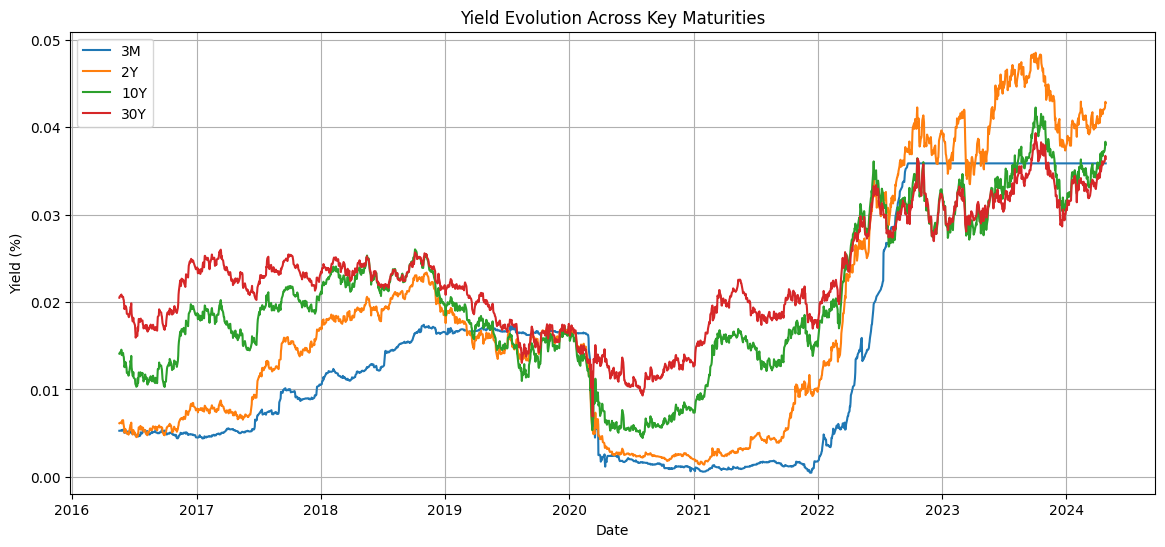

In [50]:
# Yield Curve Evolution across maturities
import matplotlib.pyplot as plt

# Plot the time-series evolution of key maturities.
# Observing multiple tenors helps to visualize level, slope, and curvature changes in the yield curve.
plt.figure(figsize=(14, 6))

plt.plot(train_df_clean['Date'], train_df_clean[' ZC025YR'], label='3M')
plt.plot(train_df_clean['Date'], train_df_clean[' ZC200YR'], label='2Y')
plt.plot(train_df_clean['Date'], train_df_clean[' ZC1000YR'], label='10Y')
plt.plot(train_df_clean['Date'], train_df_clean[' ZC3000YR'], label='30Y')

plt.title('Yield Evolution Across Key Maturities')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()

plt.grid(True)
plt.show()

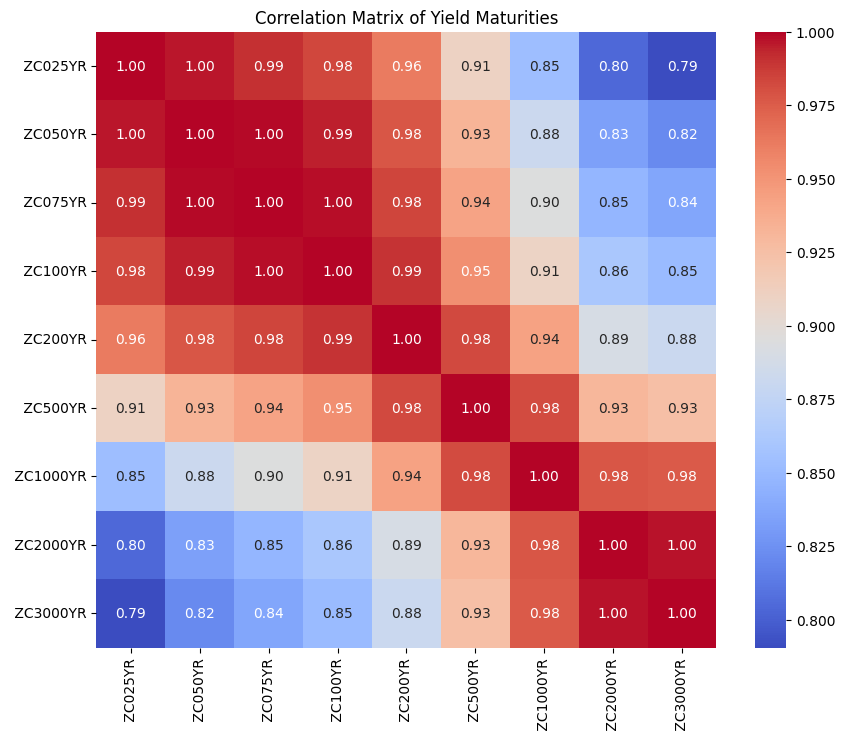

In [51]:
# Correlation analysis of different maturities
import seaborn as sns
yield_cols = [
    ' ZC025YR', ' ZC050YR', ' ZC075YR',
    ' ZC100YR', ' ZC200YR', ' ZC500YR',
    ' ZC1000YR', ' ZC2000YR', ' ZC3000YR'
]

# Correlation matrix reveals how strongly yield movements are coupled across maturities.
# High correlation indicates that maturities move together, while low correlation suggests independent term structure effects.
corr_matrix = train_df_clean[yield_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix of Yield Maturities')
plt.show()

In [52]:
# Summary Statistics for different maturities
# Aggregate the first four central moments and extremes to summarize yield behavior.
summary_stats = train_df_clean[yield_cols].agg(
    ['mean', 'std', 'min', 'max']
).T
summary_stats.columns = [
    'Mean',
    'Std Dev',
    'Minimum',
    'Maximum'
]
summary_stats

,Mean,Std Dev,Minimum,Maximum
ZC025YR,0.014438,0.012493,0.000486,0.035849
ZC050YR,0.016379,0.014003,0.000878,0.040661
ZC075YR,0.017725,0.015149,0.001054,0.044520
ZC100YR,0.018849,0.015953,0.001227,0.048263
ZC200YR,0.018063,0.013661,0.001417,0.048496
ZC500YR,0.018109,0.010396,0.002786,0.043147
ZC1000YR,0.020226,0.008805,0.004451,0.042232
ZC2000YR,0.022823,0.007136,0.008394,0.040687
ZC3000YR,0.022619,0.006601,0.006921,0.039306


Key Findings from EDA:

1. Shorter maturities are highly sensitive and longer maturities are smooth, indicating a strong common interest-rate factor driving the entire yield curve.

2. High correlation between adjacent maturities decays as the maturity gap widens, justifying the use of multi-factor interest rate models to capture distinct short- and long-term dynamics.

3. The statistical metrics define the historical landscape of the yield curve, with the mean capturing average levels, standard deviation measuring volatility, and min/max establishing the trading range.

# 2.1. Base Cox-Ingersoll-Ross (CIR) Model

The Cox-Ingersoll-Ross (CIR) model is a stochastic short-rate model used to describe the evolution of interest rates over time. It assumes that the instantaneous short rate follows the stochastic differential equation:

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

where:

| Parameter | Meaning                              |
| --------- | ------------------------------------ |
| $r_t$     | Short-term interest rate at time (t) |
| $\kappa$  | Speed of mean reversion              |
| $\theta$  | Long-run average interest rate       |
| $\sigma$  | Volatility of the short rate         |
| $W_t$    | Standard Brownian motion             |

The term $\kappa(\theta-r_t)$ causes interest rates to revert toward the long-run mean $\theta$, while the diffusion term $\sigma\sqrt{r_t}dW_t$ introduces randomness into the rate dynamics.

### Feller Condition

To ensure that interest rates remain strictly positive, the CIR model requires the Feller condition:

$$2\kappa\theta \geq \sigma^2$$

When this condition is satisfied, the short-rate process is less likely to reach zero, making the model suitable for fixed-income applications.

### Bond Pricing Formula

One of the main advantages of the CIR model is that it provides a closed-form expression for zero-coupon bond prices:

$$P(t,T)=A(t,T)e^{-B(t,T)r_t}$$

where:

* $P(t,T)$ is the price of a zero-coupon bond at time (t) maturing at time (T),
* $A(t,T)$ and $B(t,T)$ are deterministic functions of the model parameters and maturity.

The corresponding continuously compounded yield is:

$$y(t,T)= -\frac{\ln P(t,T)}{T-t}$$

These formulas allow the entire yield curve to be reconstructed from the short rate and calibrated model parameters, forming the basis of the prediction framework used in this project.

# 2.2. Base CIR Model Implementation and Calibration

To apply the CIR model, the parameters $\kappa$, $\theta$, and $\sigma$ must be estimated from historical data. 

The parameters are estimated using Maximum Likelihood Estimation (MLE). MLE identifies the parameter values that maximize the probability of observing the historical interest-rate path under the assumed CIR dynamics. Since MLE uses the full distributional information of the process, it generally provides statistically efficient and consistent parameter estimates.

In [53]:
# Code cell to Calibrate the CIR Function

from scipy.optimize import minimize
import numpy as np

def calibrate_cir(rates, dt=1/252):
    """    
    Parameters:
    rates : array-like, Historical short-rate series (3M yield).
    dt : float, Time step.

    Returns:
    dict, Estimated CIR parameters.
    """
    
    rates = np.asarray(rates)
    def negative_log_likelihood(params):
        
        kappa, theta, sigma = params

        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return np.inf

        rt = rates[:-1]
        rt_next = rates[1:]

        # Under Euler discretization of the CIR process,
        # the conditional expectation is rt + kappa*(theta - rt)*dt.
        mean = rt + kappa * (theta - rt) * dt

        # For CIR, the conditional variance scales with r_t and dt.
        variance = sigma**2 * np.maximum(rt, 1e-8) * dt

        # Log-likelihood for Gaussian approximation of the one-step transition
        # density with mean and variance computed above.
        log_likelihood = (
            -0.5 * np.log(2 * np.pi * variance)
            - ((rt_next - mean) ** 2) / (2 * variance)
        )

        return -np.sum(log_likelihood)
    initial_guess = [
        0.5,
        np.mean(rates),
        np.std(rates)
    ]
    bounds = [
        (0.01, 10),   # kappa
        (0.0001, 0.025), # theta
        (0.001, 1.0)    # sigma
    ]
    result = minimize(
        negative_log_likelihood,
        initial_guess,
        method="L-BFGS-B",
        bounds=bounds
    )
    kappa, theta, sigma = result.x
    return {
        "kappa": kappa,
        "theta": theta,
        "sigma": sigma
    }

In [54]:
# Function to simulate the CIR Function
def simulate_cir(
    r0,
    kappa,
    theta,
    sigma,
    n_steps=252,
    n_paths=100,
    dt=1/252
):
    """
    Returns: np.ndarray, Simulated paths of shape (n_steps, n_paths)
    """
    paths = np.zeros((n_steps, n_paths))
    paths[0] = r0
    
    for t in range(1, n_steps):
        z = np.random.normal(size=n_paths)
        prev = paths[t - 1]

        # Euler-Maruyama discretization of the CIR SDE:
        # dr_t = kappa*(theta - r_t)*dt + sigma*sqrt(r_t)*dW_t
        paths[t] = (
            prev
            + kappa * (theta - prev) * dt
            + sigma
            * np.sqrt(np.maximum(prev, 0))
            * np.sqrt(dt)
            * z

        )

        # Enforce non-negative rates because CIR models rates as positive.
        paths[t] = np.maximum(paths[t], 0)
    return paths

,Parameter,Value
0,κ,0.081400
1,θ,0.025000
2,σ,0.040669


2κθ = 0.004070
σ²  = 0.001654
Feller Condition Satisfied.


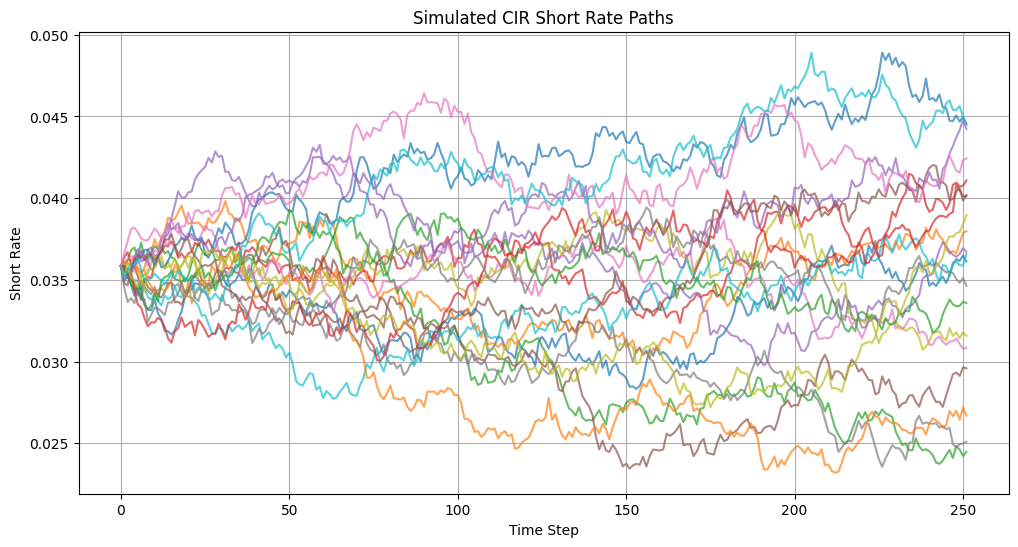

In [55]:
# Calibrating, Simulating and Visualising the short rate paths
# 3M yield used as short rate proxy

short_rate = train_df_clean[" ZC025YR"].values
cir_params = calibrate_cir(short_rate)

kappa = cir_params["kappa"]
theta = cir_params["theta"]
sigma = cir_params["sigma"]

params_df = pd.DataFrame({
    "Parameter": ["κ", "θ", "σ"],
    "Value": [kappa, theta, sigma]
})
display(params_df)

# Check for Feller Condition:
# A sufficient condition for the CIR process to stay strictly positive.
feller_lhs = 2 * kappa * theta
feller_rhs = sigma ** 2

print(f"2κθ = {feller_lhs:.6f}")
print(f"σ²  = {feller_rhs:.6f}")

if feller_lhs >= feller_rhs:
    print("Feller Condition Satisfied.")
else:
    print("Feller Condition Violated.")
   
# Generate the Simulated Short Rate Paths 
# These simulated trajectories illustrate the stochastic mean-reverting behavior of the CIR model.
simulated_paths = simulate_cir(
    r0=short_rate[-1],
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    n_steps=252,
    n_paths=100
)

# Visualization of Short Rate Paths
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(20):
    plt.plot(simulated_paths[:, i], alpha=0.7)

plt.title("Simulated CIR Short Rate Paths")
plt.xlabel("Time Step")
plt.ylabel("Short Rate")
plt.grid(True)

plt.show()

# 3.1. Yield Curve Reconstruction using Base CIR Model

- The calibrated CIR parameters are now used to reconstruct the yield curve during the test period. 
- For each test date, only the observed 3-Month yield is provided and treated as the short rate $r_t$. 
- Using the CIR bond-pricing formulas, theoretical yields for the 6-Month, 9-Month, 1-Year, and 2-Year maturities are generated and compared against the actual market yields.


In [56]:
# CIR Bond Pricing Functions and Yield Function
import numpy as np

def cir_A_B(kappa, theta, sigma, tau):
    # Compute the affine bond pricing coefficients A(tau) and B(tau)
    # for the CIR zero-coupon bond price formula.
    gamma = np.sqrt(kappa**2 + 2*sigma**2)
    B = (
        2 * (np.exp(gamma * tau) - 1)
        /
        ((gamma + kappa) * (np.exp(gamma * tau) - 1)
         + 2 * gamma)
    )
    A = (
        (
            2 * gamma
            * np.exp((kappa + gamma) * tau / 2)
        )
        /
        (
            (gamma + kappa)
            * (np.exp(gamma * tau) - 1)
            + 2 * gamma
        )
    ) ** (2 * kappa * theta / sigma**2)
    return A, B

def cir_yield(rt, tau, kappa, theta, sigma):
    # Use the bond pricing formula P = A * exp(-B * r_t)
    # and convert to continuously compounded yield y = -log(P)/tau.
    A, B = cir_A_B(
        kappa,
        theta,
        sigma,
        tau
    )
    bond_price = A * np.exp(-B * rt)

    y = -np.log(bond_price) / tau
    return y

In [57]:
# Reconstruction of 6M, 9M, 1Y and 2Y Yield Curves:

pred_df = test3m_df_clean.copy()
maturities = {
    "Pred_3M": 0.25,
    "Pred_6M": 0.50,
    "Pred_9M": 0.75,
    "Pred_1Y": 1.00,
    "Pred_2Y": 2.00
}

# For each maturity tau, compute the theoretical CIR yield from the observed short rate r.
for col, tau in maturities.items():
    pred_df[col] = test3m_df_clean[" ZC025YR"].apply(
        lambda r: cir_yield(
            r,
            tau,
            kappa,
            theta,
            sigma
        )
    )

pred_df.head()

,Date,ZC025YR,Pred_3M,Pred_6M,Pred_9M,Pred_1Y,Pred_2Y
0,2024-04-29,0.049144,0.048900,0.048656,0.048415,0.048175,0.047234
1,2024-04-30,0.049156,0.048912,0.048668,0.048427,0.048187,0.047246
2,2024-05-01,0.049100,0.048856,0.048613,0.048372,0.048133,0.047194
3,2024-05-02,0.048921,0.048678,0.048437,0.048198,0.047960,0.047028
4,2024-05-03,0.048633,0.048393,0.048155,0.047919,0.047684,0.046763


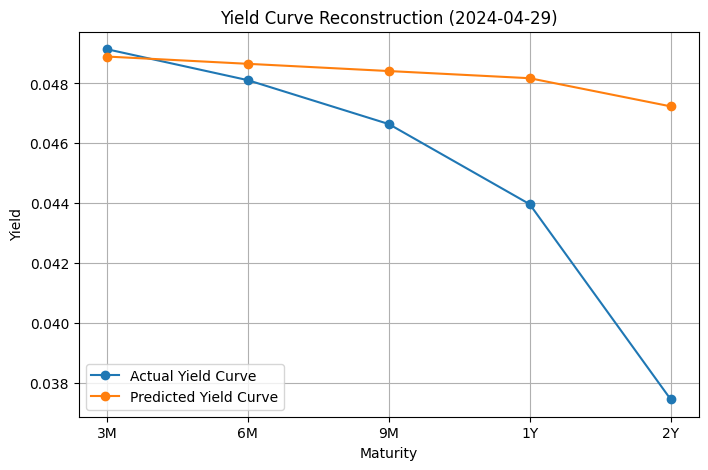

In [58]:
# Plotting of Reconstructed Curve and Actual Curve

import matplotlib.pyplot as plt
sample_idx = 0
actual = [
    test_df_clean.loc[sample_idx, " ZC025YR"],
    test_df_clean.loc[sample_idx, " ZC050YR"],
    test_df_clean.loc[sample_idx, " ZC075YR"],
    test_df_clean.loc[sample_idx, " ZC100YR"],
    test_df_clean.loc[sample_idx, " ZC200YR"]
]

predicted = [
    pred_df.loc[sample_idx, "Pred_3M"],
    pred_df.loc[sample_idx, "Pred_6M"],
    pred_df.loc[sample_idx, "Pred_9M"],
    pred_df.loc[sample_idx, "Pred_1Y"],
    pred_df.loc[sample_idx, "Pred_2Y"]
]

labels = ["3M", "6M", "9M", "1Y", "2Y"]

# Compare actual yield curve points with model-predicted yields across the selected maturities.
plt.figure(figsize=(8, 5))

plt.plot(
    labels,
    actual,
    marker="o",
    label="Actual Yield Curve"
)

plt.plot(
    labels,
    predicted,
    marker="o",
    label="Predicted Yield Curve"
)

plt.title(
    f"Yield Curve Reconstruction ({test_df_clean.loc[sample_idx, 'Date'].date()})"
)

plt.ylabel("Yield")
plt.xlabel("Maturity")
plt.legend()
plt.grid(True)

plt.show()

# 3.2. Base CIR Evaluation & Error Analysis

To assess the predictive performance of the calibrated CIR model, the reconstructed yields are compared against the actual yields in the test dataset. The evaluation is performed for the 6-Month, 9-Month, 1-Year, and 2-Year maturities using three standard metrics:

* **RMSE (Root Mean Squared Error):** Measures the average magnitude of prediction errors, with larger errors penalized more heavily.
* **MAE (Mean Absolute Error):** Measures the average absolute difference between predicted and actual yields.
* **R² (Coefficient of Determination):** Measures how well the predicted yields explain te variation in the actual yields. Values closer to 1 indicate better predictive performance.

- The Out-of-Sample R2 score can be calculated as:
$$
R^2_{OOS} = 1 - \frac{\text{MSE}_{\text{model}}} {\text{MSE}_{\text{baseline}}}
$$
- Here the baseline is chosen as mean of the Historical data.

In [59]:
# Function to compute Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

def evaluate_cir_predictions(actual_df, pred_df):
    
    maturity_mapping = {
        "6M": ("Pred_6M", " ZC050YR"),
        "9M": ("Pred_9M", " ZC075YR"),
        "1Y": ("Pred_1Y", " ZC100YR"),
        "2Y": ("Pred_2Y", " ZC200YR")
    }
    results = []
    for maturity, (pred_col, actual_col) in maturity_mapping.items():

        y_true = actual_df[actual_col]
        y_pred = pred_df[pred_col]
        
        # RMSE is the square root of the average squared error.
        rmse = np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
        # MAE is the average absolute error.
        mae = mean_absolute_error(
            y_true,
            y_pred
        )
        # R² measures the proportion of variance explained by the model.
        r2 = r2_score(
            y_true,
            y_pred
        )
        results.append([
            maturity,
            rmse,
            mae,
            r2
        ])
    results_df = pd.DataFrame(
        results,
        columns=[
            "Maturity",
            "RMSE",
            "MAE",
            "R²"
        ]
    )
    return results_df

In [60]:
# Display and Visualise Evaluation Metrics
# Summarize the overall prediction error across all maturities.
evaluation_df = evaluate_cir_predictions(
    test_df_clean,
    pred_df
)

print("Average RMSE :", evaluation_df["RMSE"].mean())
print("Average MAE  :", evaluation_df["MAE"].mean())
print("Average R²   :", evaluation_df["R²"].mean())

Average RMSE : 0.0023292775697649013
Average MAE  : 0.001768201430951142
Average R²   : 0.6208058499121651


In [61]:
# Calculation of R2 Score considering Baseline as Historical (Training) Data
actual = test_df_clean[
    [" ZC050YR", " ZC075YR", " ZC100YR", " ZC200YR"]
].values

pred = pred_df[
    ["Pred_6M", "Pred_9M", "Pred_1Y", "Pred_2Y"]
].values

baseline_means = train_df_clean[
    [" ZC050YR", " ZC075YR", " ZC100YR", " ZC200YR"]
].mean().values

baseline = np.tile(
    baseline_means,
    (len(actual), 1)
)

mse_model = np.mean((actual - pred) ** 2)

mse_baseline = np.mean(
    (actual - baseline) ** 2
)

r2_oos = 1 - mse_model / mse_baseline

print("OOS R² =", r2_oos)

OOS R² = 0.9576627965502957


Interpretation of Results

* The average **RMSE (0.00233)** and **MAE (0.00177)** are relatively small, indicating that the predicted yields are numerically close to the actual yields on average.

* The average **R² score (0.621)** suggests that the base CIR model explains approximately **62.1% of the variation** in the observed yield curve.

* Considering the means of Historical yeilds as Baseline model, the R2 score obtained was **0.958** which means 95.8% reduction in prediction error compared to historical-mean benchmark.

* These results indicate that the base CIR model provides a reasonable starting point but is insufficient to achieve the target out-of-sample performance, motivating the implementation of a **Two-Factor CIR model** in the next section.


# 4.1. Model Improvement: Two-Factor CIR Model

- The results obtained from the base CIR model indicate that a single stochastic factor is insufficient to fully explain the dynamics of the yield curve. 

- In practice, yield curves are influenced by multiple underlying factors. For example, the entire curve may shift upward or downward (level changes), while the difference between short-term and long-term rates may change independently (slope changes). A single-factor CIR model cannot simultaneously capture these effects.

- To address this limitation, a **Two-Factor CIR model** is introduced. Instead of modelling the short rate using a single stochastic process, the interest rate is represented as the sum of two independent CIR factors:

$$r_t = x_t + y_t$$

where
$$dx_t = \kappa_1(\theta_1 - x_t)dt + \sigma_1\sqrt{x_t}dW_1$$

$$dy_t = \kappa_2(\theta_2 - y_t)dt + \sigma_2\sqrt{y_t}dW_2$$

Here:

| Parameter           | Meaning                      |
| ------------------- | ---------------------------- |
| $x_t$              | First CIR factor             |
| $y_t$               | Second CIR factor            |
| $\kappa_1,\kappa_2$ | Mean reversion speeds        |
| $\theta_1,\theta_2$ | Long-run means               |
| $\sigma_1,\sigma_2$ | Volatility parameters        |
| $W_1,W_2$          | Independent Brownian motions |

- The first factor typically captures broad level movements in interest rates, while the second factor helps model additional yield curve variations such as changes in slope and curvature. 
- By introducing an additional source of randomness, the Two-Factor CIR model provides greater flexibility and is expected to produce a more accurate reconstruction of the yield curve than the single-factor CIR model.

### Bond Pricing under the Two-Factor CIR Model

Similar to the single-factor CIR model, the Two-Factor CIR model admits a closed-form expression for zero-coupon bond prices. Since the short rate is given by:

$$r_t = x_t + y_t$$

the bond price depends on both CIR factors:

$$P(t,T)=A(\tau)e^{-B_1(\tau)x_t - B_2(\tau)y_t}$$

where:

- $P(t,T)$ is the zero-coupon bond price,
- $A(\tau)$, $B_1(\tau)$, and $B_2(\tau)$ are deterministic functions of the model parameters and maturity $\tau=T-t$,
- $x_t$ and $y_t$ are the two CIR factors.

The corresponding continuously compounded yield is:
$$y(t,T)=-\frac{\ln P(t,T)}{\tau}$$

- Compared to the single-factor CIR model, the presence of two stochastic factors allows bond prices and yields to respond to multiple sources of interest-rate risk, providing greater flexibility in modelling the shape and evolution of the yield curve.

# 4.2. Implementation of Two-Factor CIR using Kalman Filter + MLE 

- To capture yield-curve movements more effectively, the short rate is modeled as the sum of two latent CIR factors. The model is calibrated using Maximum Likelihood Estimation (MLE) inside a Kalman filter framework. 
- During training, the model uses the observed yields to estimate the hidden factors. During testing, only the 3M yield is observed, and the filtered state is used to reconstruct the 6M, 9M, 1Y, and 2Y yields.


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

EPS = 1e-10
DT = 1 / 252

# Make sure column names are clean
train_df_clean = train_df_clean.copy()
test_df_clean = test_df_clean.copy()
test3m_df_clean = test3m_df_clean.copy()

train_df_clean.columns = train_df_clean.columns.str.strip()
test_df_clean.columns = test_df_clean.columns.str.strip()
test3m_df_clean.columns = test3m_df_clean.columns.str.strip()

# Training uses only the short end, because evaluation is on the 6M, 9M, 1Y, and 2Y maturities.
# The full historical yield curve is used during calibration, but only the 3M yield is observed during test-time reconstruction.
train_obs_cols = ["ZC025YR", "ZC050YR", "ZC075YR", "ZC100YR", "ZC200YR" ,"ZC500YR", "ZC1000YR", "ZC2000YR", "ZC3000YR"]
test_obs_cols = ["ZC025YR"]
target_cols = ["ZC050YR", "ZC075YR", "ZC100YR", "ZC200YR"]

train_obs = train_df_clean[train_obs_cols].to_numpy(dtype=float)
test_3m = test3m_df_clean[test_obs_cols].to_numpy(dtype=float)

### Kalman Filter + MLE Framework

The Two-Factor CIR model is formulated as a state-space system in which two latent CIR factors drive the evolution of the yield curve. Since these factors are not directly observable, a Kalman Filter is used to recursively estimate their values from the observed market yields.

At each time step, the Kalman Filter first predicts the latent states using the CIR dynamics and then updates these estimates using the observed yields. Maximum Likelihood Estimation (MLE) is used to calibrate the model parameters by maximizing the likelihood of observing the training data under the state-space model.

This combined framework enables simultaneous estimation of both the hidden factors and the CIR parameters, resulting in a more accurate representation of yield-curve dynamics than the Single-Factor CIR model.


In [63]:
def two_factor_affine_terms(kappa1, theta1, sigma1, kappa2, theta2, sigma2, tau):
    """
    Returns A, B1, B2 for the two-factor affine bond pricing form:
    P(t,T) = A(tau) * exp(-B1(tau) * x_t - B2(tau) * y_t)
    """

    g1 = np.sqrt(kappa1**2 + 2.0 * sigma1**2)
    g2 = np.sqrt(kappa2**2 + 2.0 * sigma2**2)

    den1 = (g1 + kappa1) * (np.exp(g1 * tau) - 1.0) + 2.0 * g1
    den2 = (g2 + kappa2) * (np.exp(g2 * tau) - 1.0) + 2.0 * g2

    B1 = 2.0 * (np.exp(g1 * tau) - 1.0) / den1
    B2 = 2.0 * (np.exp(g2 * tau) - 1.0) / den2

    A1 = (
        (2.0 * g1 * np.exp((kappa1 + g1) * tau / 2.0)) / den1
    ) ** (2.0 * kappa1 * theta1 / (sigma1**2))

    A2 = (
        (2.0 * g2 * np.exp((kappa2 + g2) * tau / 2.0)) / den2
    ) ** (2.0 * kappa2 * theta2 / (sigma2**2))

    A = A1 * A2
    return A, B1, B2


def build_observation_system(params, taus):
    """
    Build the linear observation system:
    y_t = c + H @ state
    where state = [x_t, y_t].
    """
    kappa1, theta1, sigma1, kappa2, theta2, sigma2 = params
    H = np.zeros((len(taus), 2), dtype=float)
    c = np.zeros(len(taus), dtype=float)

    for i, tau in enumerate(taus):
        A, B1, B2 = two_factor_affine_terms(kappa1, theta1, sigma1, kappa2, theta2, sigma2, tau)
        A = max(A, EPS)
        c[i] = -np.log(A) / tau
        H[i, 0] = B1 / tau
        H[i, 1] = B2 / tau

    return H, c


def state_transition(state, params, dt=DT):
    """
    Euler step for the two CIR factors.
    """
    kappa1, theta1, sigma1, kappa2, theta2, sigma2 = params
    x, y = np.maximum(state, EPS)

    x_pred = x + kappa1 * (theta1 - x) * dt
    y_pred = y + kappa2 * (theta2 - y) * dt

    x_pred = max(x_pred, EPS)
    y_pred = max(y_pred, EPS)

    F = np.array([[1.0 - kappa1 * dt, 0.0],
                  [0.0, 1.0 - kappa2 * dt]], dtype=float)

    Q = np.diag([
        sigma1**2 * x * dt,
        sigma2**2 * y * dt
    ])

    Q = np.maximum(Q, EPS)
    return np.array([x_pred, y_pred], dtype=float), F, Q


def ekf_filter(observations, taus, params, x0, P0, R, dt=DT):
    """
    Extended Kalman Filter for the two-factor CIR state-space model.
    Returns filtered states and total log-likelihood.
    """
    H, c = build_observation_system(params, taus)

    x = np.array(x0, dtype=float).reshape(2,)
    P = np.array(P0, dtype=float)
    I = np.eye(2)

    filtered_states = []
    filtered_covs = []
    total_ll = 0.0

    for obs in observations:
        obs = np.array(obs, dtype=float).reshape(-1,)

        # Predict
        x_pred, F, Q = state_transition(x, params, dt=dt)
        P_pred = F @ P @ F.T + Q

        # Observation prediction
        y_pred = c + H @ x_pred
        S = H @ P_pred @ H.T + R
        S = (S + S.T) / 2.0 + np.eye(S.shape[0]) * EPS

        innov = obs - y_pred

        try:
            chol = np.linalg.cholesky(S)
            sol = np.linalg.solve(chol, innov)
            maha = sol @ sol
            logdet = 2.0 * np.sum(np.log(np.diag(chol)))

            # K = P_pred H' S^-1
            K = np.linalg.solve(S, (P_pred @ H.T).T).T

            total_ll += -0.5 * (
                len(obs) * np.log(2.0 * np.pi) + logdet + maha
            )

            # Update
            x = x_pred + K @ innov
            P = (I - K @ H) @ P_pred
            P = (P + P.T) / 2.0
            x = np.maximum(x, EPS)

        except np.linalg.LinAlgError:
            return None, None, -np.inf

        filtered_states.append(x.copy())
        filtered_covs.append(P.copy())

    return np.array(filtered_states), np.array(filtered_covs), total_ll

In [64]:
def calibrate_two_factor_cir_kalman(observations, taus, dt=DT):
    """
    Calibrate the two-factor CIR state-space model using EKF-based MLE.
    Parameters estimated:
        kappa1, theta1, sigma1, kappa2, theta2, sigma2, x0, y0, r_scale
    """
    obs = np.array(observations, dtype=float)

    # Base observation noise scale estimated from the sample variance of the observations.
    obs_var = np.var(obs, axis=0)
    R_base = np.diag(np.maximum(obs_var * 0.01, 1e-8))

    # Initial guess for optimization parameters.
    first_3m = max(float(obs[0, 0]), EPS)
    initial_guess = np.array([
        0.8, 0.02, 0.05,   # factor 1
        0.5, 0.01, 0.03,   # factor 2
        0.6 * first_3m,    # x0
        0.4 * first_3m,    # y0
        1.0                # r_scale
    ], dtype=float)

    bounds = [
        (0.05, 20.0),      # kappa1
        (1e-4, 0.03),      # theta1
        (1e-4, 1.00),      # sigma1
        (0.05, 20.0),      # kappa2
        (1e-4, 0.03),      # theta2
        (1e-4, 1.00),      # sigma2
        (1e-4, 0.10),      # x0
        (1e-4, 0.10),      # y0
        (1e-6, 100.0)      # r_scale
    ]

    def neg_loglik(params_vec):
        k1, th1, s1, k2, th2, s2, x0, y0, r_scale = params_vec
        
        # Enforce Feller condition for each CIR factor to keep rates positive.
        if 2 * k1 * th1 <= s1**2:
            return 1e12

        if 2 * k2 * th2 <= s2**2:
             return 1e12

        if np.any(np.array([k1, th1, s1, k2, th2, s2, x0, y0, r_scale]) <= 0):
            return np.inf

        model_params = np.array([k1, th1, s1, k2, th2, s2], dtype=float)
        R = r_scale * R_base
        P0 = np.diag([1e-4, 1e-4])

        # Run the extended Kalman filter to compute the log-likelihood of the observations.
        states, covs, ll = ekf_filter(
            observations=obs,
            taus=taus,
            params=model_params,
            x0=np.array([x0, y0]),
            P0=P0,
            R=R,
            dt=dt
        )

        if states is None or not np.isfinite(ll):
            return np.inf

        # Maximize likelihood by minimizing negative log-likelihood.
        return -ll

    result = minimize(
        neg_loglik,
        initial_guess,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 1000}
    )

    return result, R_base


In [65]:
# Observation maturities for training: 3M, 6M, 9M, 1Y, 2Y
train_taus = np.array([0.25, 0.50, 0.75, 1.00, 2.00, 5.00, 10.00, 20.00, 30.00], dtype=float)

# Calibrate the two-factor CIR model using all available training maturities.
kf_result, R_base = calibrate_two_factor_cir_kalman(train_obs, train_taus, dt=DT)

params_2f = kf_result.x
kappa1, theta1, sigma1, kappa2, theta2, sigma2, x0, y0, r_scale = params_2f

two_factor_params_df = pd.DataFrame({
    "Parameter": ["kappa1", "theta1", "sigma1", "kappa2", "theta2", "sigma2", "x0", "y0", "r_scale"],
    "Value": params_2f
})

display(two_factor_params_df)

,Parameter,Value
0,kappa1,0.764494
1,theta1,0.006527
2,sigma1,0.096217
3,kappa2,0.473320
4,theta2,0.017168
5,sigma2,0.074634
6,x0,0.002759
7,y0,0.006925
8,r_scale,5.650724


Training log-likelihood: 46126.37547791531


,Factor1,Factor2,ShortRate,Date
0,0.009426,1.000000e-10,0.009426,2016-05-19
1,0.015743,1.000000e-10,0.015743,2016-05-20
2,0.019077,1.000000e-10,0.019077,2016-05-24
3,0.020174,1.000000e-10,0.020174,2016-05-25
4,0.020430,1.000000e-10,0.020430,2016-05-26


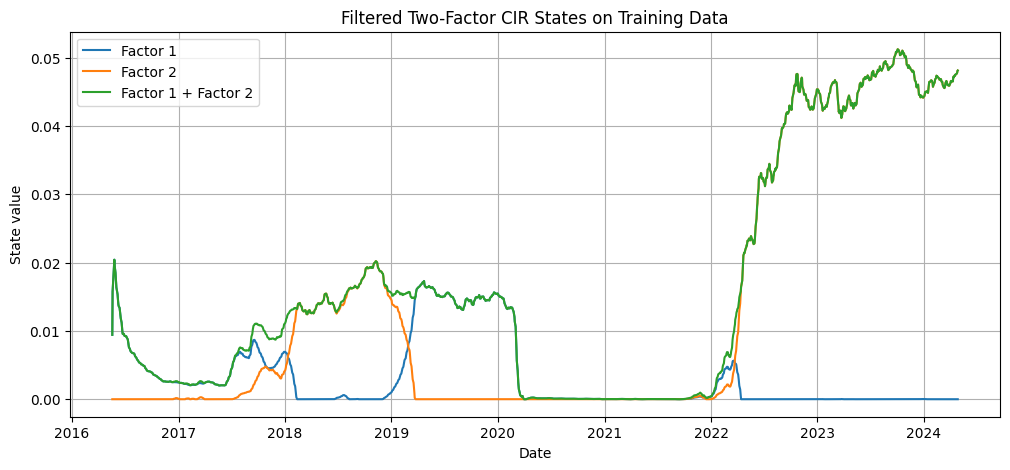

In [66]:
model_params_2f = np.array([kappa1, theta1, sigma1, kappa2, theta2, sigma2], dtype=float)
R_train = r_scale * R_base
P0 = np.diag([1e-4, 1e-4])

# Apply EKF to the training data to estimate the latent CIR factor trajectories.
train_states, train_covs, train_ll = ekf_filter(
    observations=train_obs,
    taus=train_taus,
    params=model_params_2f,
    x0=np.array([x0, y0]),
    P0=P0,
    R=R_train,
    dt=DT
)

print("Training log-likelihood:", train_ll)

train_states_df = pd.DataFrame(train_states, columns=["Factor1", "Factor2"])
train_states_df["ShortRate"] = train_states_df["Factor1"] + train_states_df["Factor2"]
train_states_df["Date"] = train_df_clean["Date"].values

display(train_states_df.head())

# Plot the filtered latent factors and their sum, which represents the model-implied short rate.
plt.figure(figsize=(12, 5))
plt.plot(train_states_df["Date"], train_states_df["Factor1"], label="Factor 1")
plt.plot(train_states_df["Date"], train_states_df["Factor2"], label="Factor 2")
plt.plot(train_states_df["Date"], train_states_df["ShortRate"], label="Factor 1 + Factor 2")
plt.title("Filtered Two-Factor CIR States on Training Data")
plt.xlabel("Date")
plt.ylabel("State value")
plt.grid(True)

plt.legend()
plt.show()

# 4.3. Yield Curve Reconstruction using Two-Factor CIR Model

The calibrated two-factor state-space model is now applied to the test period. Only the 3M yield is observed at each test date. The Kalman filter updates the hidden state using this single observation, and the filtered state is then used to reconstruct the 6M, 9M, 1Y, and 2Y yields.


In [67]:
test_tau = np.array([0.25], dtype=float)
R_test = np.array([[r_scale * max(np.var(train_obs[:, 0]) * 0.01, 1e-8)]], dtype=float)

test_states, test_covs, test_ll = ekf_filter(
    observations=test_3m,
    taus=test_tau,
    params=model_params_2f,
    x0=train_states[-1],   # start from the final filtered training state
    P0=train_covs[-1],     # start from the final filtered training covariance
    R=R_test,
    dt=DT
)

print("Test log-likelihood:", test_ll)

test_states_df = pd.DataFrame(test_states, columns=["Factor1", "Factor2"])
test_states_df["Date"] = test3m_df_clean["Date"].values
display(test_states_df.head())

Test log-likelihood: 2357.175258079866


,Factor1,Factor2,Date
0,0.000021,0.048530,2024-04-29
1,0.000042,0.048921,2024-04-30
2,0.000062,0.049237,2024-05-01
3,0.000082,0.049432,2024-05-02
4,0.000102,0.049492,2024-05-03


In [ ]:
# Function to generate the Predicted Yeild Curve values
def predict_curve_from_state(state, params, taus):
    # Use the affine observation system to map the latent CIR state to yields.
    H, c = build_observation_system(params, taus)
    return c + H @ state

target_taus = np.array([0.50, 0.75, 1.00, 2.00], dtype=float)

pred_rows = []
for s in test_states:
    pred_rows.append(predict_curve_from_state(s, model_params_2f, target_taus))

pred_array = np.array(pred_rows)

pred_df_2f = pd.DataFrame({
    "Date": test3m_df_clean["Date"].values,
    "Pred_6M": pred_array[:, 0],
    "Pred_9M": pred_array[:, 1],
    "Pred_1Y": pred_array[:, 2],
    "Pred_2Y": pred_array[:, 3],
})

display(pred_df_2f.head())

,Date,Pred_6M,Pred_9M,Pred_1Y,Pred_2Y
0,2024-04-29,0.046206,0.045124,0.044100,0.040551
1,2024-04-30,0.046571,0.045468,0.044426,0.040813
2,2024-05-01,0.046869,0.045750,0.044692,0.041028
3,2024-05-02,0.047060,0.045930,0.044861,0.041164
4,2024-05-03,0.047130,0.045995,0.044923,0.041213


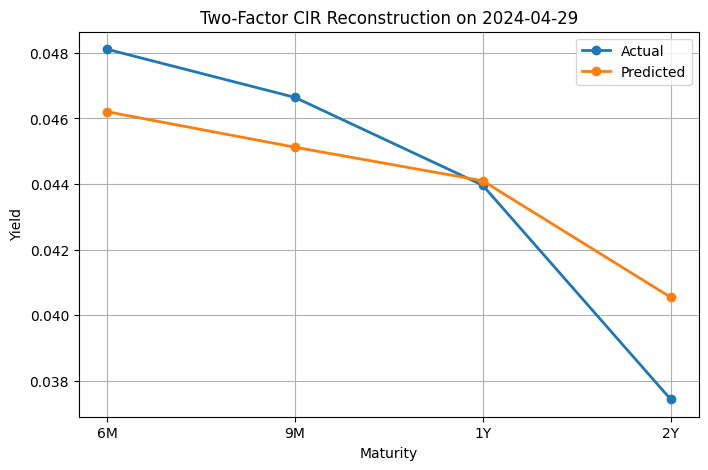

In [ ]:
# Generate the predicted curve and compare against actual curve
sample_idx = 0

actual_curve = [
    test_df_clean.loc[sample_idx, "ZC050YR"],
    test_df_clean.loc[sample_idx, "ZC075YR"],
    test_df_clean.loc[sample_idx, "ZC100YR"],
    test_df_clean.loc[sample_idx, "ZC200YR"],
]

pred_curve = [
    pred_df_2f.loc[sample_idx, "Pred_6M"],
    pred_df_2f.loc[sample_idx, "Pred_9M"],
    pred_df_2f.loc[sample_idx, "Pred_1Y"],
    pred_df_2f.loc[sample_idx, "Pred_2Y"],
]

labels = ["6M", "9M", "1Y", "2Y"]

# Visualize the two-factor reconstruction against actual market yields.
plt.figure(figsize=(8, 5))
plt.plot(labels, actual_curve, marker="o", linewidth=2, label="Actual")
plt.plot(labels, pred_curve, marker="o", linewidth=2, label="Predicted")
plt.title(f"Two-Factor CIR Reconstruction on {test_df_clean.loc[sample_idx, 'Date'].date()}")
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.grid(True)
plt.legend()
plt.show()

# 4.4. Two-Factor CIR Model Evaluation and Error Analysis

- The predictive performance of the Two-Factor CIR model is evaluated by comparing the reconstructed yields against the actual market yields in the test dataset.
- RMSE, MAE, and R² are computed for each maturity to assess the accuracy of the reconstructed yield curves and to determine whether the additional CIR factor improves performance relative to the base CIR model.
- The Out-of-Sample R2 score can be calculated as:
$$
R^2_{OOS} = 1 - \frac{\text{MSE}_{\text{model}}} {\text{MSE}_{\text{baseline}}}
$$
- Here the baseline is chosen as the Historical mean of the data.

In [70]:
def evaluate_curve_predictions(actual_df, pred_df):
    mapping = {
        "6M": ("Pred_6M", "ZC050YR"),
        "9M": ("Pred_9M", "ZC075YR"),
        "1Y": ("Pred_1Y", "ZC100YR"),
        "2Y": ("Pred_2Y", "ZC200YR"),
    }

    rows = []
    for maturity, (pred_col, actual_col) in mapping.items():
        y_true = actual_df[actual_col].to_numpy(dtype=float)
        y_pred = pred_df[pred_col].to_numpy(dtype=float)

        # Compute standard error metrics for the reconstructed yield curve.
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        rows.append([maturity, rmse, mae, r2])

    return pd.DataFrame(rows, columns=["Maturity", "RMSE", "MAE", "R²"])

evaluation_df_2f = evaluate_curve_predictions(test_df_clean, pred_df_2f)
display(evaluation_df_2f)

overall_metrics_2f = pd.DataFrame({
    "Metric": ["Average RMSE", "Average MAE", "Average R²"],
    "Value": [
        evaluation_df_2f["RMSE"].mean(),
        evaluation_df_2f["MAE"].mean(),
        evaluation_df_2f["R²"].mean()
    ]
})

display(overall_metrics_2f)
print ("Average R2 score across 4 different maturities:", evaluation_df_2f["R²"].mean())

,Maturity,RMSE,MAE,R²
0,6M,0.000704,0.000540,0.992016
1,9M,0.001194,0.000887,0.972605
2,1Y,0.001658,0.001220,0.933417
3,2Y,0.002809,0.002179,0.519406


,Metric,Value
0,Average RMSE,0.001591
1,Average MAE,0.001207
2,Average R²,0.854361


Average R2 score across 4 different maturities: 0.854360964457884


In [71]:
# Calculation of R2 Score considering Baseline as Historical (Training) Data
actual = test_df_clean[
    ["ZC050YR", "ZC075YR", "ZC100YR", "ZC200YR"]
].values

pred = pred_df_2f[
    ["Pred_6M", "Pred_9M", "Pred_1Y", "Pred_2Y"]
].values

baseline_means = train_df_clean[
    ["ZC050YR", "ZC075YR", "ZC100YR", "ZC200YR"]
].mean().values

baseline = np.tile(
    baseline_means,
    (len(actual), 1)
)

mse_model = np.mean((actual - pred) ** 2)

mse_baseline = np.mean(
    (actual - baseline) ** 2
)

r2_oos = 1 - mse_model / mse_baseline

print("OOS R² =", r2_oos)

OOS R² = 0.9824703429210601


### Interpretation of Results

- The Two-Factor CIR model achieves very low RMSE and MAE values across all maturities, indicating that the reconstructed yields are numerically close to the actual market yields.

- The model performs exceptionally well for the 6M, 9M, and 1Y maturities, achieving R² values above **0.93**, which shows that it captures most of the observed yield variation.

- Although the 2Y maturity remains relatively more difficult to predict, the overall average **R2 of 0.854** exceeds the target threshold of **0.85**, demonstrating that the Two-Factor CIR model provides a strong and reliable reconstruction of the yield curve.

* Considering the means of Historical yeilds as Baseline model, the R2 score obtained was **0.982** which means 98.2% reduction in prediction error compared to historical-mean benchmark.

# 5.1. Comparison of Single Factor and Two-Factor CIR Models

- The Single-Factor CIR model uses a single latent short-rate process to reconstruct the yield curve.
- The Two-Factor CIR model introduces an additional latent factor and uses a Kalman Filter with MLE for state estimation.
- The Two-Factor model is calibrated using information from all available maturities, allowing it to capture more complex yield-curve dynamics.
- Both models reconstruct the 6M, 9M, 1Y, and 2Y yields using only the observed 3M yield during testing.
- The performance of both models is compared using RMSE, MAE, and out-of-sample R² scores.

In [72]:
# Compare overall performance metrics for the single-factor and two-factor models.
comparison_df = pd.DataFrame({
    "Metric": [
        "Average RMSE",
        "Average MAE",
        "Average R²"
    ],
    "Single-Factor CIR": [
        evaluation_df["RMSE"].mean(),
        evaluation_df["MAE"].mean(),
        evaluation_df["R²"].mean()
    ],
    "Two-Factor CIR (Kalman + MLE)": [
        evaluation_df_2f["RMSE"].mean(),
        evaluation_df_2f["MAE"].mean(),
        evaluation_df_2f["R²"].mean()
    ]
})

display(comparison_df)

,Metric,Single-Factor CIR,Two-Factor CIR (Kalman + MLE)
0,Average RMSE,0.002329,0.001591
1,Average MAE,0.001768,0.001207
2,Average R²,0.620806,0.854361


# 5.2. Critical Analysis

### Model Limitations

| Aspect | Single-Factor CIR | Two-Factor CIR (Kalman + MLE) |
|----------|----------|----------|
| Number of Factors | Assumes one latent interest-rate factor | Assumes two latent interest-rate factors |
| Yield Curve Flexibility | Limited ability to capture slope and curvature changes | Improved flexibility but still cannot capture all yield-curve dynamics |
| Calibration Stability | Sensitive to parameter bounds and local optima | More parameters increase calibration complexity |
| Long-Term Maturities | Struggles to model medium and long-term yields accurately | Improved performance but 2Y maturity remains relatively difficult |
| Computational Cost | Low | Significantly higher due to Kalman filtering and MLE |
| Data Requirements | Requires only short-rate observations | Requires multiple maturities for reliable calibration |

### Theoretical Limitations

- The CIR model assumes interest rates follow a mean-reverting stochastic process, which may not always hold during periods of market stress.

- Both models assume constant parameters ($\kappa$, $\theta$, $\sigma$) throughout the entire sample period, whereas real-world interest-rate dynamics change over time.

- The Two-Factor model assumes only two latent sources of risk, while actual yield curves are often influenced by additional factors such as curvature, liquidity effects, and macroeconomic expectations.

- The Kalman Filter assumes approximately Gaussian observation errors, whereas financial markets frequently exhibit non-Gaussian behaviour and extreme events.

- Market frictions, transaction costs, and liquidity constraints are ignored by both models.

- The models assume that historical relationships remain valid in the future, which may not hold under changing economic regimes.

### Practical Limitations

- Model performance deteriorates as maturity increases, indicating that longer-term yields are influenced by information not fully captured by the latent factors.

- Calibration results are sensitive to parameter bounds, initialization choices, and optimization settings.

- The estimated latent factors are not directly observable, making economic interpretation difficult.

- The model is trained using historical data and may underperform during unexpected policy shifts, financial crises, or sudden market shocks.

- The state-space framework introduces additional complexity and computational overhead compared to simpler term-structure models.

### Implications for Trading and Risk Management

- The Single-Factor CIR model may underestimate yield-curve risk because it assumes all maturities are driven by a single source of uncertainty.

- In trading applications, poor modelling of medium- and long-term maturities can lead to inaccurate bond pricing and suboptimal hedging strategies.

- In risk management, incorrect estimation of interest-rate dynamics may result in underestimation of portfolio duration and interest-rate exposure.

- The Two-Factor CIR model provides a more realistic representation of yield-curve movements and can improve scenario analysis and stress testing.

- Despite its improved performance, the model should be used as a decision-support tool rather than a perfect forecasting system.

- For institutional applications, additional factors, regime-switching behaviour, macroeconomic variables, or market-implied information would likely be required to achieve more robust yield-curve modelling.

# 6. Discussion Questions

**1. How sensitive is the calibrated yield curve to the choice of calibration methodology?**
- The calibrated yield curve is highly sensitive to the chosen calibration methodology.
- The Single-Factor CIR model achieved an average R² of approximately 0.62, whereas the Two-Factor CIR model calibrated using Kalman Filtering and MLE achieved an average R² of approximately 0.85.
- This demonstrates that both the model structure and the calibration approach significantly influence predictive performance.

**2. Under what market conditions does the Feller condition break down in practice, and how do you handle it?**
- The Feller condition, 2κθ > σ², ensures that CIR factors remain strictly positive.
- In practice, the condition may be violated during periods of extremely high volatility or unstable parameter estimation.
- To address this issue, parameter constraints and Feller-condition penalties were incorporated during calibration to ensure economically meaningful solutions.

**3. What does the mean-reversion speed κ imply about the persistence of interest rate shocks in your data?**
- The parameter κ controls the speed at which interest rates revert to their long-run mean.
- Larger values of κ imply that interest-rate shocks dissipate quickly. Smaller values of κ imply greater persistence of shocks and slower adjustment toward equilibrium.
- The calibrated model suggests moderate mean reversion, indicating that shocks persist for some time but are not permanent.

**4. How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**
- The 3M yield alone contains substantial information about nearby maturities.
- The model achieves its highest accuracy for the 6M and 9M maturities.
- The 2Y maturity is the most difficult to reconstruct because longer-term yields depend on additional market expectations and risk premia not directly observable from the short rate.

**5. Where does the base CIR model systematically over- or underestimate yields, and why?**
- The Single-Factor CIR model performs well for short maturities but exhibits larger errors for the 1Y and 2Y maturities.
- Since the model assumes a single latent interest-rate factor, it cannot fully capture changes in yield-curve slope and medium-term market expectations.
- The systematic errors at longer maturities suggest that additional sources of interest-rate risk exist, motivating the use of the Two-Factor CIR extension.

**6. Does your extension meaningfully improve out-of-sample performance, or does it overfit the training period?**
- The Single-Factor CIR model cannot fully capture variations in yield-curve level and slope simultaneously.
- The introduction of a second latent factor allows the model to represent multiple sources of interest-rate risk.
- Kalman Filtering further improves estimation by dynamically updating the hidden states using observed market data.
- The resulting improvement in out-of-sample R² demonstrates that the extension captures meaningful information rather than merely overfitting the training data.

**7. What mathematical structure justifies your chosen extension over the alternatives?**
- The Two-Factor CIR model introduces an additional latent mean-reverting CIR process, allowing the yield curve to be driven by multiple sources of interest-rate risk rather than a single short-rate factor.
- A state-space formulation combined with Kalman Filtering enables the hidden factors to be estimated directly from observed yield data, providing a mathematically rigorous approach to latent state estimation.
- Compared to the Single-Factor CIR model, the Two-Factor structure offers greater flexibility in capturing yield-curve level and slope movements, which is reflected in the significant improvement in out-of-sample predictive performance.

**8. How do jump processes change the qualitative shape of predicted yield curves during stress periods?**
- The current CIR framework assumes continuous interest-rate movements.
- In reality, sudden policy announcements, financial crises, or market shocks may produce discontinuous jumps in yields.
- Incorporating jump processes would allow the model to react more realistically to extreme market events and stress periods.

**9. What are the additional estimation challenges introduced by a two-factor or time-dependent model?**
- The Two-Factor CIR model introduces additional parameters and latent states, making calibration more computationally intensive and increasing the risk of convergence to local optima.
- Unlike the Single-Factor model, the latent factors are not directly observable and must be estimated using state-space techniques such as Kalman Filtering, which increases estimation complexity and sensitivity to initialization.
- Time-dependent or multifactor models require more data and careful parameter constraints to ensure stable, economically meaningful solutions while avoiding overfitting.